In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Plotting libraries
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(color_codes = True)
%matplotlib inline

##### Scikit Learn modules needed for Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder,MinMaxScaler , StandardScaler

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
##loading data
train_df =pd.read_csv("../input/titanic/train.csv")
test_df = pd.read_csv("../input/titanic/test.csv")

In [3]:
##now joinning train and testdataset for data processing
full_df = train_df.append(test_df, ignore_index=True)
print(f'There are {full_df.shape[0]} rows and {full_df.shape[1]} columns in the full dataframe.')

There are 1309 rows and 12 columns in the full dataframe.


In [4]:
full_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
full_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB


In [6]:
full_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,1309.000000,891.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,655.000000,0.383838,2.294882,29.881138,0.498854,0.385027,33.295479
std,378.020061,0.486592,0.837836,14.413493,1.041658,0.865560,51.758668
min,1.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,328.000000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,655.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,982.000000,1.000000,3.000000,39.000000,1.000000,0.000000,31.275000
max,1309.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200


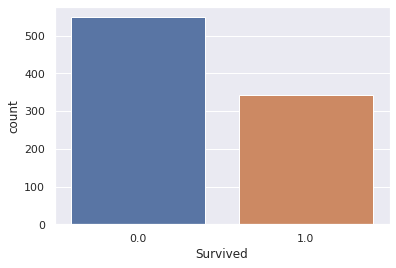

In [7]:
sns.set_style('darkgrid')
sns.countplot(data=full_df,x='Survived')
plt.show()


In [8]:
## here we can see that 350 peoples are survived and near about 550 people died in this disaster

In [9]:
#function for converting male and female into 0 and 1

def clean_string(x):
    if x == 'female':
        return 1
    else:
        return 0


In [10]:
df_clean = full_df
df_clean['Sex'] = df_clean['Sex'].apply(clean_string)

In [11]:
df_clean.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S


## 4. visualize data

<AxesSubplot:>

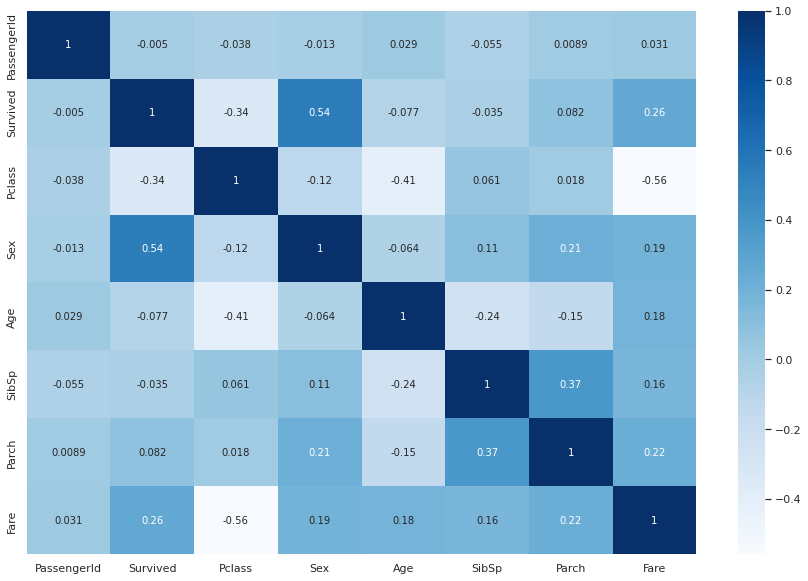

In [12]:
## correlation will give relation between each variable
correlation = df_clean.corr()
plt.figure(figsize=(15,10) )
sns.heatmap(correlation,annot = True,cmap = 'Blues')

### above plot we can see that for survived  sex which depend +0.54 and fare depend +0.26 

In [13]:
df_clean.drop(['PassengerId','Name','SibSp','Parch','Ticket','Cabin','Embarked'],axis='columns',inplace=True)
## dropping column which dont have any relation in data

In [14]:
df_clean.head()

,Survived,Pclass,Sex,Age,Fare
0,0.0,3,0,22.0,7.2500
1,1.0,1,1,38.0,71.2833
2,1.0,3,1,26.0,7.9250
3,1.0,1,1,35.0,53.1000
4,0.0,3,0,35.0,8.0500


In [15]:
df_clean.isnull().sum()

Survived    418
Pclass        0
Sex           0
Age         263
Fare          1
dtype: int64

In [16]:
df_clean1 = df_clean.dropna()

In [17]:
df_clean1.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
Fare        0
dtype: int64

In [18]:
df_clean1.info

<bound method DataFrame.info of      Survived  Pclass  Sex   Age     Fare
0         0.0       3    0  22.0   7.2500
1         1.0       1    1  38.0  71.2833
2         1.0       3    1  26.0   7.9250
3         1.0       1    1  35.0  53.1000
4         0.0       3    0  35.0   8.0500
..        ...     ...  ...   ...      ...
885       0.0       3    1  39.0  29.1250
886       0.0       2    0  27.0  13.0000
887       1.0       1    1  19.0  30.0000
889       1.0       1    0  26.0  30.0000
890       0.0       3    0  32.0   7.7500

[714 rows x 5 columns]>

In [19]:
inputs = df_clean1.drop('Survived',axis='columns')
target = df_clean1.Survived

In [20]:
inputs

,Pclass,Sex,Age,Fare
0,3,0,22.0,7.2500
1,1,1,38.0,71.2833
2,3,1,26.0,7.9250
3,1,1,35.0,53.1000
4,3,0,35.0,8.0500
...,...,...,...,...
885,3,1,39.0,29.1250
886,2,0,27.0,13.0000
887,1,1,19.0,30.0000
889,1,0,26.0,30.0000


In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(inputs,target,test_size=0.3,random_state= 20)

### 6. Build Logistic Regression Model

In [22]:
clf = LogisticRegression()
clf.fit(X_train, y_train)
y_predicted = clf.predict(X_test)
score = clf.score(X_test, y_test)

In [23]:
print(score)

0.813953488372093


### 7. Naive bayes model

In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(inputs,target,test_size=0.3)

In [25]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()

In [26]:
model.fit(X_train,y_train)

GaussianNB()

In [27]:
model.score(X_test,y_test)

0.772093023255814

### 8. Random forest model

In [28]:
from sklearn.ensemble import RandomForestClassifier

In [29]:
# Build Model
clf = RandomForestClassifier(criterion= "entropy",bootstrap = False,n_estimators = 1000,n_jobs = 2,verbose = 1,max_features =3)

In [30]:
clf.fit(X_train, y_train)
y_predicted = clf.predict(X_test)
score= clf.score(X_test, y_test)

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.3s
[Parallel(n_jobs=2)]: Done 446 tasks      | elapsed:    0.8s
[Parallel(n_jobs=2)]: Done 796 tasks      | elapsed:    1.4s
[Parallel(n_jobs=2)]: Done 1000 out of 1000 | elapsed:    1.7s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 446 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 796 tasks      | elapsed:    0.2s
[Parallel(n_jobs=2)]: Done 1000 out of 1000 | elapsed:    0.2s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Paral

In [31]:
print(score)

0.7953488372093023


## Conclusion - in this problem logistic regression gives best result which is 81.39%

In [32]:
##knn
from sklearn.neighbors import KNeighborsClassifier


model1 = KNeighborsClassifier(n_neighbors = 4)
model1.fit(X_train,y_train)
prediction_knn=model1.predict(X_test)
score= model1.score(X_test, y_test)

In [33]:
print(score)

0.6604651162790698


In [34]:
#perceptron deep learning
from sklearn.linear_model import Perceptron

In [35]:
p= Perceptron()

In [36]:
p.fit(X_train,y_train)

Perceptron()

In [37]:
y_pred=p.predict(X_test)
y_pred

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [38]:
score=p.score(X_test,y_test)
print(score)

0.5534883720930233
